In [ ]:
import os, random, shutil
from pathlib import Path

def resplit_dataset(src_root, dst_root, train_ratio=0.70, val_ratio=0.15, seed=42):
    """Pools train+test images together and creates a fresh train/valid/test split."""
    src_root = Path(src_root)
    dst_root = Path(dst_root)

    # Gather every image+label pair from both existing train/ and test/
    all_pairs = []
    for split in ["train", "test"]:
        img_dir = src_root / split / "images"
        lbl_dir = src_root / split / "labels"
        if not img_dir.exists():
            continue
        for img_path in list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")):
            lbl_path = lbl_dir / (img_path.stem + ".txt")
            all_pairs.append((img_path, lbl_path if lbl_path.exists() else None))

    print(f"Total pooled images: {len(all_pairs)}")

    random.seed(seed)
    random.shuffle(all_pairs)

    n_total = len(all_pairs)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    splits = {
        "train": all_pairs[:n_train],
        "valid": all_pairs[n_train:n_train + n_val],
        "test": all_pairs[n_train + n_val:]
    }

    for split_name, pairs in splits.items():
        img_out = dst_root / split_name / "images"
        lbl_out = dst_root / split_name / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for img_path, lbl_path in pairs:
            shutil.copy(img_path, img_out / img_path.name)
            if lbl_path:
                shutil.copy(lbl_path, lbl_out / lbl_path.name)

        print(f"{split_name}: {len(pairs)} images")

# Source is read-only input, destination is your working copy
resplit_dataset(
    src_root="/kaggle/input/datasets/sudheeranguluri4642/spacecraftdetection",
    dst_root="/kaggle/working/spacecraftdetection_fixed"
)

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

In [ ]:
!pip install ultralytics -q

In [4]:
!pip install ultralytics --no-deps -q
!pip install opencv-python-headless pyyaml pandas matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.4 MB/s eta 0:00:00a 0:00:01


In [ ]:
from ultralytics import YOLO
import pandas as pd

# Point this at your actual debris11-class data.yaml path
DATA_YAML = "/kaggle/input/datasets/sudheeranguluri4642/debris11-class/data.yaml"

models_to_run = {
    "yolov8n": "yolov8n.pt",
    "yolov10n": "yolov10n.pt",
    "yolo11n": "yolo11n.pt",
}

results_summary = []

for run_name, weights in models_to_run.items():
    print(f"\n{'='*50}\nTraining {run_name}\n{'='*50}")
    
    model = YOLO(weights)
    results = model.train(
        data=DATA_YAML,
        epochs=100,
        imgsz=640,
        batch=16,
        patience=20,          # early stopping if no improvement
        name=f"milestone1_{run_name}",
        project="/kaggle/working/runs"
    )
    
    # Validate to get clean final metrics
    metrics = model.val()
    
    results_summary.append({
        "model": run_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "precision": metrics.box.mp,
        "recall": metrics.box.mr,
    })

# Comparison table
df = pd.DataFrame(results_summary)
print("\nMilestone 1 Results — debris11-class only:")
print(df.to_string(index=False))
df.to_csv("/kaggle/working/milestone1_comparison.csv", index=False)

In [ ]:
import os, shutil, random
from pathlib import Path

# ---------- CONFIG ----------
DEBRIS_SRC = Path("/kaggle/input/datasets/sudheeranguluri4642/debris11-class")
SPACECRAFT_SRC = Path("/kaggle/input/datasets/sudheeranguluri4642/spacecraftdetection")
MERGED_ROOT = Path("/kaggle/working/merged_m2")

SPACECRAFT_CLASS_ID = 11  # new remapped id

# ---------- STEP 1: Create merged folder structure ----------
for split in ["train", "valid", "test"]:
    (MERGED_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

# ---------- STEP 2: Copy debris11-class as-is (class ids 0-10 already correct) ----------
for split in ["train", "valid", "test"]:
    src_img = DEBRIS_SRC / split / "images"
    src_lbl = DEBRIS_SRC / split / "labels"
    if not src_img.exists():
        continue
    for img in src_img.glob("*.*"):
        shutil.copy(img, MERGED_ROOT / split / "images" / img.name)
    for lbl in src_lbl.glob("*.txt"):
        shutil.copy(lbl, MERGED_ROOT / split / "labels" / lbl.name)

print("Debris11-class copied.")

# ---------- STEP 3: Pool spacecraftdetection train+test, resplit 70/15/15 ----------
all_pairs = []
for split in ["train", "test"]:
    img_dir = SPACECRAFT_SRC / split / "images"
    lbl_dir = SPACECRAFT_SRC / split / "labels"
    if not img_dir.exists():
        continue
    for img_path in list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        all_pairs.append((img_path, lbl_path if lbl_path.exists() else None))

print(f"Spacecraft pooled images: {len(all_pairs)}")

random.seed(42)
random.shuffle(all_pairs)
n_total = len(all_pairs)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

sc_splits = {
    "train": all_pairs[:n_train],
    "valid": all_pairs[n_train:n_train + n_val],
    "test": all_pairs[n_train + n_val:]
}

# ---------- STEP 4: Copy spacecraft images + remap labels into merged folder ----------
for split_name, pairs in sc_splits.items():
    for img_path, lbl_path in pairs:
        # avoid filename collisions with debris dataset
        new_name = f"sc_{img_path.name}"
        shutil.copy(img_path, MERGED_ROOT / split_name / "images" / new_name)

        new_lbl_path = MERGED_ROOT / split_name / "labels" / f"sc_{img_path.stem}.txt"
        if lbl_path and lbl_path.exists():
            with open(lbl_path) as f_in, open(new_lbl_path, "w") as f_out:
                for line in f_in:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    # remap class id (spacecraftdetection only has class 0 -> becomes 11)
                    parts[0] = str(SPACECRAFT_CLASS_ID)
                    f_out.write(" ".join(parts) + "\n")

    print(f"Spacecraft {split_name}: {len(pairs)} images merged.")

# ---------- STEP 5: Write master data.yaml ----------
yaml_content = f"""train: train/images
val: valid/images
test: test/images

nc: 12
names: ['cheops', 'debris', 'double_start', 'earth_observation_sat_1', 'lisa_pathfinder', 'proba_2', 'proba_3_csc', 'proba_3_ocs', 'smart_1', 'soho', 'xmm_newton', 'spacecraft']
"""

with open(MERGED_ROOT / "data.yaml", "w") as f:
    f.write(yaml_content)

print("\nMerge complete. Final counts:")
for split in ["train", "valid", "test"]:
    n_imgs = len(list((MERGED_ROOT / split / "images").glob("*.*")))
    print(f"  {split}: {n_imgs} images")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data="/kaggle/working/merged_m2/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    name="milestone2_yolov8n",
    project="/kaggle/working/runs"
)

metrics = model.val()
print("Milestone 2 — mAP50:", metrics.box.map50, "| mAP50-95:", metrics.box.map)

In [3]:
import re
from pathlib import Path
import shutil

def extract_frame_number(filename):
    match = re.search(r'img_(\d+)', filename)
    return int(match.group(1)) if match else None

def block_split_by_frame(src_root, dst_root, train_ratio=0.70, val_ratio=0.15, gap_buffer=10):
    src_root = Path(src_root)
    dst_root = Path(dst_root)

    all_images = []
    for split in ["train", "test"]:
        img_dir = src_root / split / "images"
        if img_dir.exists():
            all_images.extend(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))

    # sort strictly by frame number — no shuffling
    frame_info = [(extract_frame_number(p.name), p) for p in all_images]
    frame_info = [f for f in frame_info if f[0] is not None]
    frame_info.sort(key=lambda x: x[0])

    n_total = len(frame_info)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    # apply a buffer gap at each cut point to drop a few boundary frames entirely
    # this prevents near-duplicate frames right at the split line from leaking across
    train_set = frame_info[:n_train - gap_buffer]
    val_set = frame_info[n_train + gap_buffer : n_train + n_val - gap_buffer]
    test_set = frame_info[n_train + n_val + gap_buffer:]

    splits = {"train": train_set, "valid": val_set, "test": test_set}

    for split_name, items in splits.items():
        img_out = dst_root / split_name / "images"
        lbl_out = dst_root / split_name / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        count = 0
        for num, img_path in items:
            for split in ["train", "test"]:
                lbl_path = src_root / split / "labels" / (img_path.stem + ".txt")
                if lbl_path.exists():
                    shutil.copy(img_path, img_out / img_path.name)
                    shutil.copy(lbl_path, lbl_out / (img_path.stem + ".txt"))
                    count += 1
                    break
        print(f"{split_name}: {count} images (frame range {items[0][0]}-{items[-1][0]})" if items else f"{split_name}: 0 images")

block_split_by_frame(
    src_root="/kaggle/input/datasets/sudheeranguluri4642/spacecraftdetection",
    dst_root="/kaggle/working/spacecraftdetection_blocksplit"
)

train: 1989 images (frame range 714-2730)
valid: 408 images (frame range 2751-3158)
test: 419 images (frame range 3179-3597)


In [8]:
import shutil
from pathlib import Path

DEBRIS_SRC = Path("/kaggle/input/datasets/sudheeranguluri4642/debris11-class")
SPACECRAFT_SRC = Path("/kaggle/working/spacecraftdetection_blocksplit")  # <-- corrected source
MERGED_ROOT = Path("/kaggle/working/merged_m2_fixed")  # <-- new folder, keep old one for comparison

SPACECRAFT_CLASS_ID = 11

# Fresh folder structure
for split in ["train", "valid", "test"]:
    (MERGED_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

# Copy debris11-class as-is
for split in ["train", "valid", "test"]:
    src_img = DEBRIS_SRC / split / "images"
    src_lbl = DEBRIS_SRC / split / "labels"
    if not src_img.exists():
        continue
    for img in src_img.glob("*.*"):
        shutil.copy(img, MERGED_ROOT / split / "images" / img.name)
    for lbl in src_lbl.glob("*.txt"):
        shutil.copy(lbl, MERGED_ROOT / split / "labels" / lbl.name)

print("Debris11-class copied.")

# Copy spacecraft (already split correctly) + remap class id to 11
for split in ["train", "valid", "test"]:
    src_img = SPACECRAFT_SRC / split / "images"
    src_lbl = SPACECRAFT_SRC / split / "labels"
    if not src_img.exists():
        continue

    count = 0
    for img_path in src_img.glob("*.*"):
        new_name = f"sc_{img_path.name}"
        shutil.copy(img_path, MERGED_ROOT / split / "images" / new_name)

        lbl_path = src_lbl / (img_path.stem + ".txt")
        new_lbl_path = MERGED_ROOT / split / "labels" / f"sc_{img_path.stem}.txt"
        if lbl_path.exists():
            with open(lbl_path) as f_in, open(new_lbl_path, "w") as f_out:
                for line in f_in:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    parts[0] = str(SPACECRAFT_CLASS_ID)
                    f_out.write(" ".join(parts) + "\n")
        count += 1
    print(f"Spacecraft {split}: {count} images merged.")

# Write data.yaml
yaml_content = """train: train/images
val: valid/images
test: test/images

nc: 12
names: ['cheops', 'debris', 'double_start', 'earth_observation_sat_1', 'lisa_pathfinder', 'proba_2', 'proba_3_csc', 'proba_3_ocs', 'smart_1', 'soho', 'xmm_newton', 'spacecraft']
"""
with open(MERGED_ROOT / "data.yaml", "w") as f:
    f.write(yaml_content)

print("\nFinal counts:")
for split in ["train", "valid", "test"]:
    n = len(list((MERGED_ROOT / split / "images").glob("*.*")))
    print(f"  {split}: {n} images")

Debris11-class copied.
Spacecraft train: 1989 images merged.
Spacecraft valid: 408 images merged.
Spacecraft test: 419 images merged.

Final counts:
  train: 4094 images
  valid: 647 images
  test: 542 images


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data="/kaggle/working/merged_m2_fixed/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    name="combined_data_yonov8n",
    project="/kaggle/working/runs"
)

metrics = model.val()
print("mAP50:", metrics.box.map50, "| mAP50-95:", metrics.box.map)

# Per-class breakdown again
class_names = metrics.names
for i, name in class_names.items():
    p = metrics.box.p[i]
    r = metrics.box.r[i]
    ap50 = metrics.box.ap50[i]
    ap = metrics.box.ap[i]
    print(f"{name:25s}  P={p:.3f}  R={r:.3f}  mAP50={ap50:.3f}  mAP50-95={ap:.3f}")

In [6]:
import random, shutil
from pathlib import Path

def create_val_split(src_root, dst_root, val_ratio=0.15, seed=42):
    src_root = Path(src_root)
    dst_root = Path(dst_root)

    for split in ["train", "test"]:
        (dst_root / split / "images").mkdir(parents=True, exist_ok=True)
        (dst_root / split / "labels").mkdir(parents=True, exist_ok=True)
    (dst_root / "valid" / "images").mkdir(parents=True, exist_ok=True)
    (dst_root / "valid" / "labels").mkdir(parents=True, exist_ok=True)

    # copy test as-is, untouched
    test_img_dir = src_root / "test" / "images"
    test_lbl_dir = src_root / "test" / "labels"
    for img in test_img_dir.glob("*.*"):
        shutil.copy(img, dst_root / "test" / "images" / img.name)
    for lbl in test_lbl_dir.glob("*.txt"):
        shutil.copy(lbl, dst_root / "test" / "labels" / lbl.name)

    # random split train -> train/valid
    train_img_dir = src_root / "train" / "images"
    train_lbl_dir = src_root / "train" / "labels"
    images = list(train_img_dir.glob("*.jpg")) + list(train_img_dir.glob("*.png"))

    random.seed(seed)
    random.shuffle(images)
    n_val = int(len(images) * val_ratio)
    val_images = images[:n_val]
    train_images = images[n_val:]

    for img in train_images:
        shutil.copy(img, dst_root / "train" / "images" / img.name)
        lbl = train_lbl_dir / (img.stem + ".txt")
        if lbl.exists():
            shutil.copy(lbl, dst_root / "train" / "labels" / lbl.name)

    for img in val_images:
        shutil.copy(img, dst_root / "valid" / "images" / img.name)
        lbl = train_lbl_dir / (img.stem + ".txt")
        if lbl.exists():
            shutil.copy(lbl, dst_root / "valid" / "labels" / lbl.name)

    print(f"train: {len(train_images)} | valid: {len(val_images)} | test: {len(list((dst_root/'test'/'images').glob('*.*')))}")

create_val_split(
    src_root="/kaggle/input/datasets/sudheeranguluri4642/asteroidclassification",
    dst_root="/kaggle/working/asteroid_split"
)

train: 595 | valid: 105 | test: 100


In [9]:
from pathlib import Path
import shutil

ASTEROID_SRC = Path("/kaggle/working/asteroid_split")
MERGED_ROOT = Path("/kaggle/working/merged_m3")  # new folder, keeps m2_fixed intact for comparison
PREV_MERGED = Path("/kaggle/working/merged_m2_fixed")

ASTEROID_CLASS_ID = 12

# Start by copying everything from merged_m2_fixed (debris11 + spacecraft)
shutil.copytree(PREV_MERGED, MERGED_ROOT, dirs_exist_ok=True)

# Add asteroid, remapped to class 12
for split in ["train", "valid", "test"]:
    src_img = ASTEROID_SRC / split / "images"
    src_lbl = ASTEROID_SRC / split / "labels"
    if not src_img.exists():
        continue

    count = 0
    for img_path in src_img.glob("*.*"):
        new_name = f"ast_{img_path.name}"
        shutil.copy(img_path, MERGED_ROOT / split / "images" / new_name)

        lbl_path = src_lbl / (img_path.stem + ".txt")
        new_lbl_path = MERGED_ROOT / split / "labels" / f"ast_{img_path.stem}.txt"
        if lbl_path.exists():
            with open(lbl_path) as f_in, open(new_lbl_path, "w") as f_out:
                for line in f_in:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    parts[0] = str(ASTEROID_CLASS_ID)
                    f_out.write(" ".join(parts) + "\n")
        count += 1
    print(f"Asteroid {split}: {count} images merged.")

# Update data.yaml
yaml_content = """train: train/images
val: valid/images
test: test/images

nc: 13
names: ['cheops', 'debris', 'double_start', 'earth_observation_sat_1', 'lisa_pathfinder', 'proba_2', 'proba_3_csc', 'proba_3_ocs', 'smart_1', 'soho', 'xmm_newton', 'spacecraft', 'asteroid']
"""
with open(MERGED_ROOT / "data.yaml", "w") as f:
    f.write(yaml_content)

print("\nFinal Milestone 3 counts:")
for split in ["train", "valid", "test"]:
    n = len(list((MERGED_ROOT / split / "images").glob("*.*")))
    print(f"  {split}: {n} images")

Asteroid train: 595 images merged.
Asteroid valid: 105 images merged.
Asteroid test: 100 images merged.

Final Milestone 3 counts:
  train: 4689 images
  valid: 752 images
  test: 642 images


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data="/kaggle/working/merged_m3/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    name="milestone3_yolov8n",
    project="/kaggle/working/runs"
)

metrics = model.val()
print("mAP50:", metrics.box.map50, "| mAP50-95:", metrics.box.map)

class_names = metrics.names
for i, name in class_names.items():
    print(f"{name:25s}  P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}  mAP50={metrics.box.ap50[i]:.3f}  mAP50-95={metrics.box.ap[i]:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/merged_m3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv

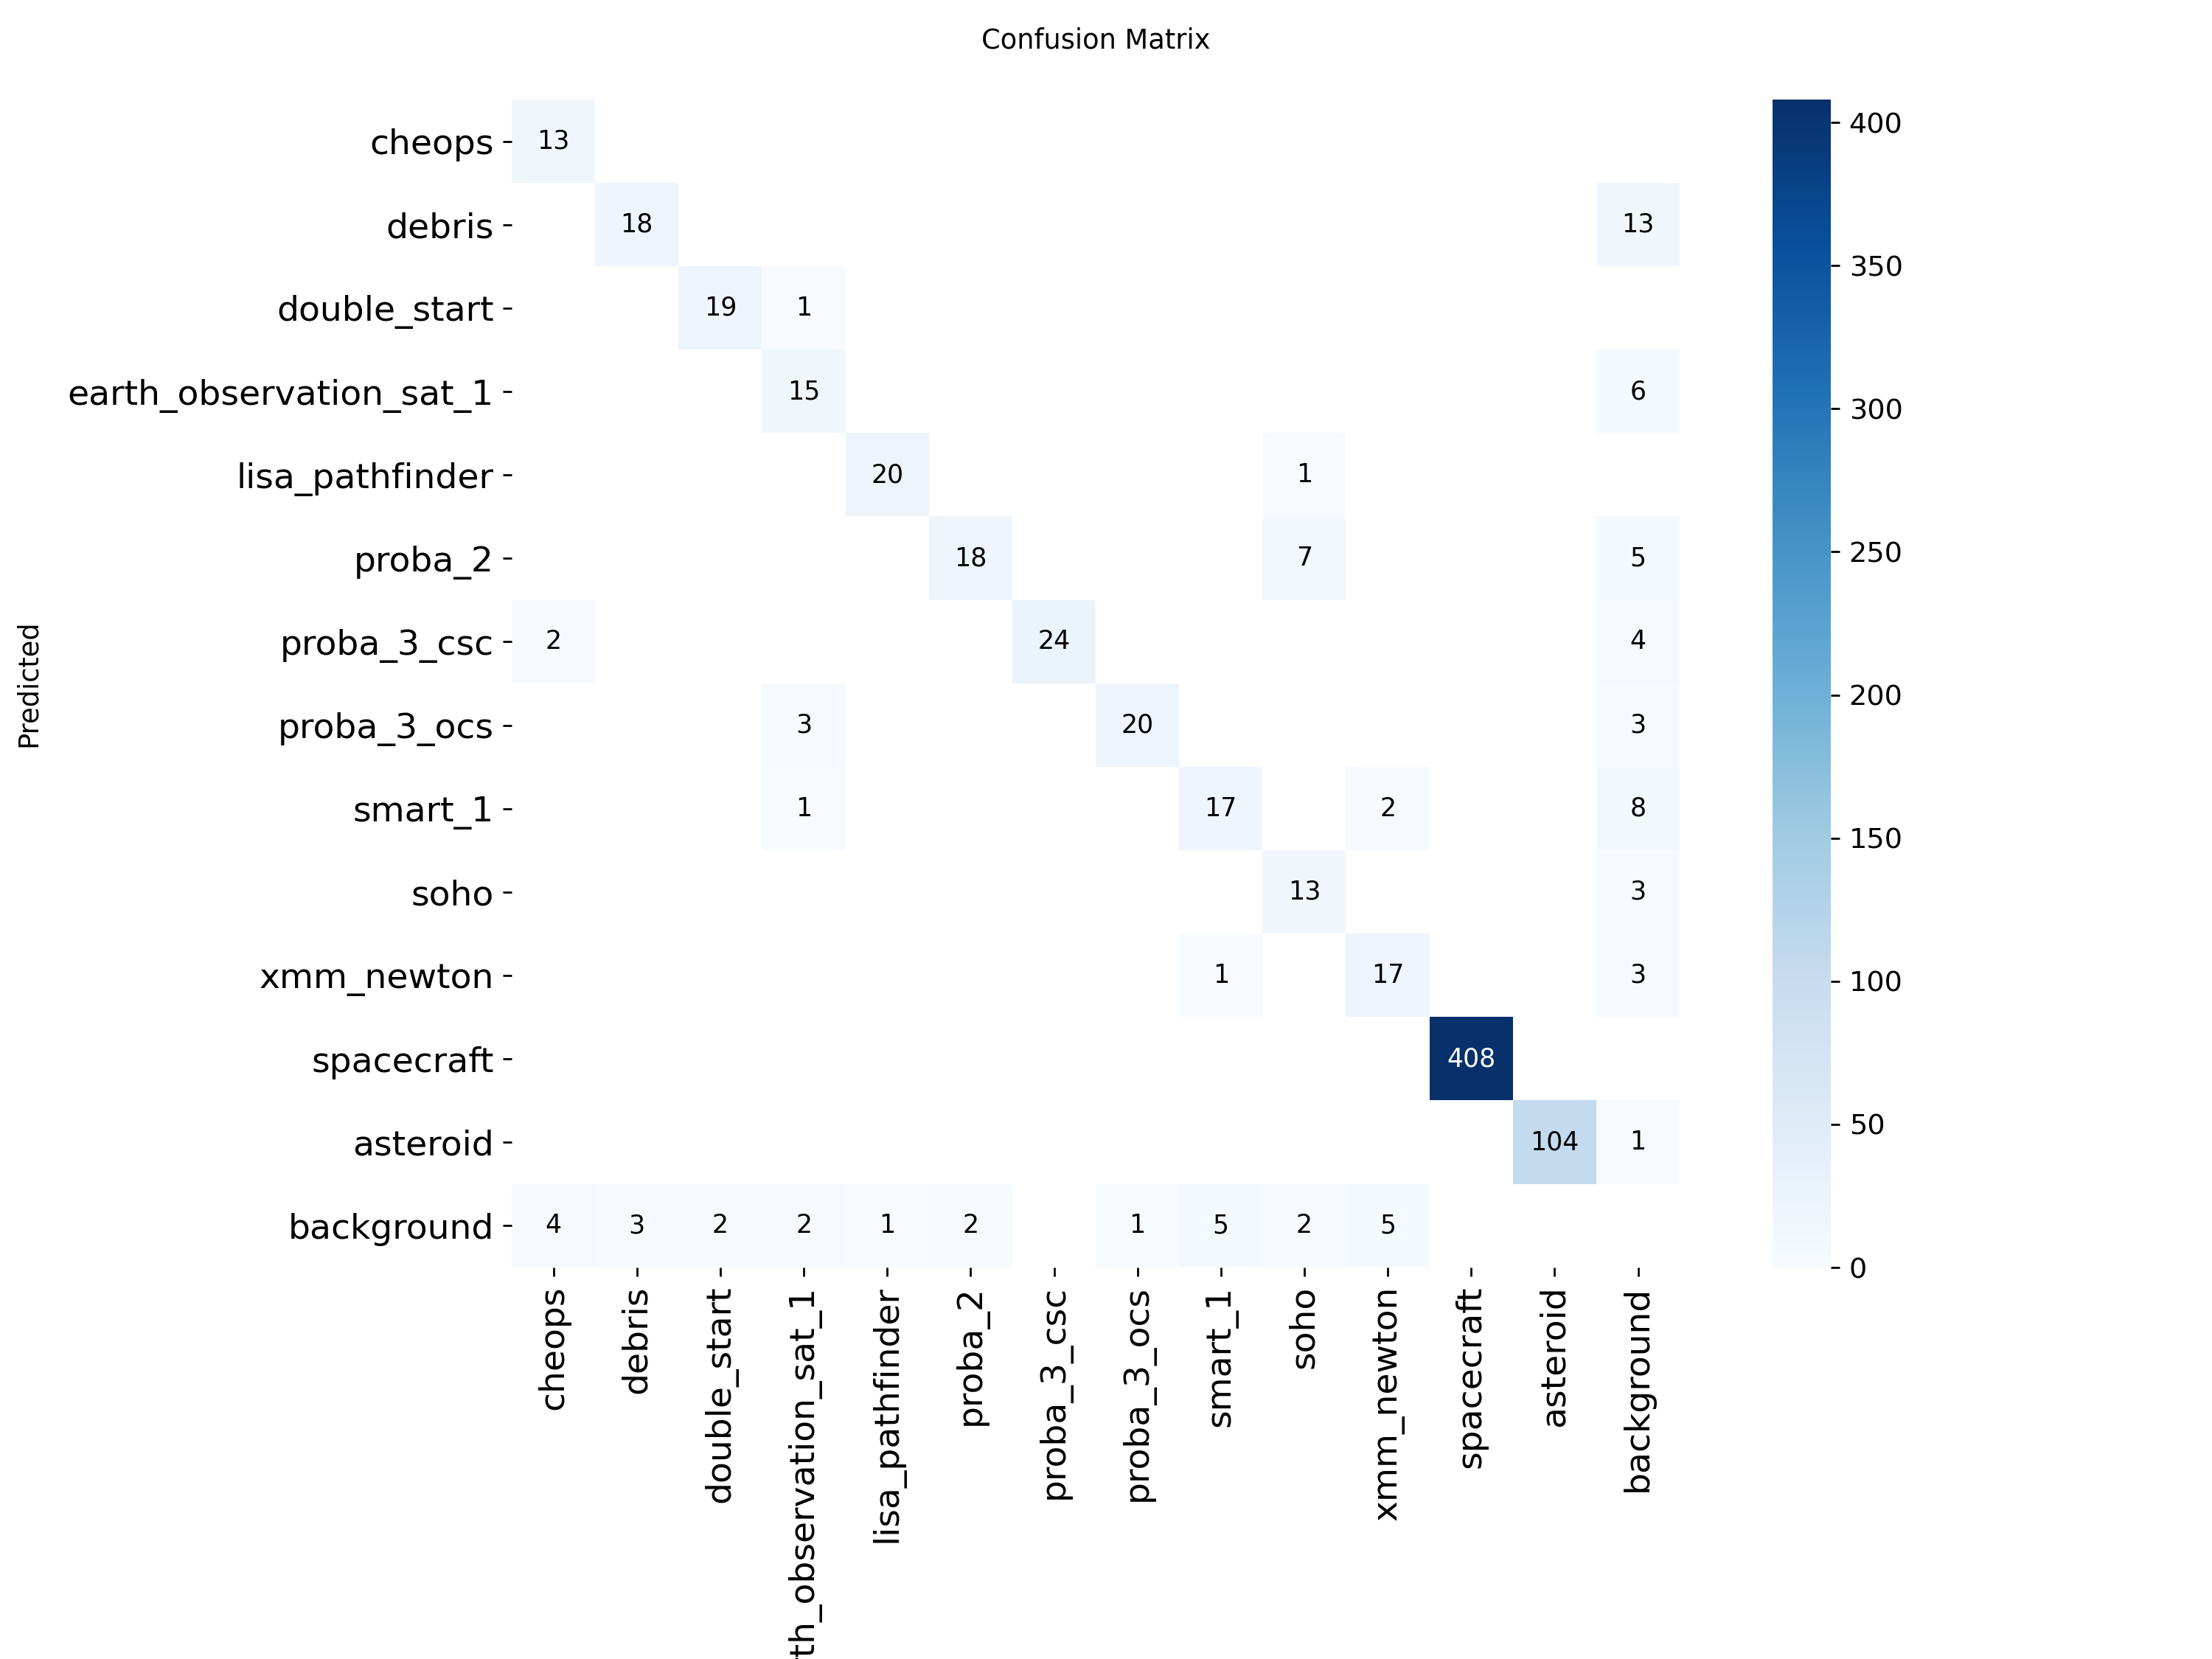

In [12]:
from IPython.display import Image as IPImage
IPImage("/kaggle/working/runs/milestone3_yolov8n/confusion_matrix.png")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

result_grid = model.tune(
    data="/kaggle/working/merged_m3/data.yaml",
    epochs=30,          # short epochs per trial, not full 100
    iterations=5,       # number of hyperparameter combinations to try
    optimizer="AdamW",
    plots=False,          # keep off during search to save time/disk
    save=False,
    val=True,
    project="/kaggle/working/tune_runs",
    name="tune_yolov8n"
)

Tuner: Initialized Tuner instance with 'tune_dir=/kaggle/working/tune_runs/tune_yolov8n'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/20 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos

In [ ]:
model11 = YOLO("yolo11n.pt")

result_grid_11 = model11.tune(
    data="/kaggle/working/merged_m3/data.yaml",
    epochs=30,
    iterations=10,
    optimizer="AdamW",
    plots=False,
    save=False,
    val=True,
    project="/kaggle/working/tune_runs",
    name="tune_yolo11n"
)